In [15]:
#import dataset to notebook

'''
#upload csv file to notebook
from google.colab import files
uploaded = files.upload()
'''
import pandas as pd


data = pd.read_csv("../data/raw/Customer-Data.csv")
data

,Customer ID,Title,First Name,Middle Name,Last Name,Suffix,Street Address1,Street Address2,City-ZipCode-State,Birth Date,...,Occupation,Gender,Marital Status,Home Owner Status,Number of Cars Owned,Number of Children At Home,Total Number of Children,Annual Income,Avg Monthly Spend,eBook Subscriber Flag
0,11000,NaN,Jon,V,Yang,NaN,3761 N. 14th St,NaN,Cleveland-44101-Ohio,4/8/66,...,Professional,M,M,1,0,0,2,137947,89,0
1,11001,NaN,Eugene,L,Huang,NaN,2243 W St.,NaN,Seattle-98101-Washington,5/14/65,...,Professional,M,S,0,1,3,3,101141,117,1
2,11002,NaN,Ruben,NaN,Torres,NaN,5844 Linden Land,NaN,Omaha-68101-Nebraska,8/12/65,...,Professional,M,M,1,1,3,3,91945,123,0
3,11003,NaN,Christy,NaN,Zhu,NaN,1825 Village Pl.,NaN,Fort Worth-76101-Texas,2/15/68,...,Professional,F,S,0,1,0,0,86688,50,0
4,11004,NaN,Elizabeth,NaN,Johnson,NaN,7553 Harness Circle,NaN,Oakland-94601-California,8/8/68,...,Professional,F,S,1,4,5,5,92771,95,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16514,13121,NaN,Latasha,E,Jimenez,NaN,7259 Birchwood,NaN,San Antonio-78201-Texas,3/22/65,...,Professional,F,M,1,4,5,5,101542,101,0
16515,26100,NaN,James,Garner,Ptaszynski,NaN,7345 Kenwal Rd.,NaN,Pittsburgh-15201-Pennsylvania,4/2/36,...,Professional,F,S,1,2,0,3,46549,46,0
16516,11328,NaN,Julian,M,Griffin,NaN,7398 Withersed Lane,NaN,Honolulu-96801-Hawaii,1/1/40,...,Management,M,M,1,2,0,5,133053,79,0
16517,23077,NaN,Marvin,A,Hernandez,NaN,1019 Book Road,NaN,Anaheim-92801-California,10/20/46,...,Skilled Manual,M,M,1,2,0,4,31930,65,0


In [16]:
#display dataset columns
data.columns

Index(['Customer ID', 'Title', 'First Name', 'Middle Name', 'Last Name',
       'Suffix', 'Street Address1', 'Street Address2', 'City-ZipCode-State',
       'Birth Date', 'Education Level', 'Occupation', 'Gender',
       'Marital Status', 'Home Owner Status', 'Number of Cars Owned',
       'Number of Children At Home', 'Total Number of Children',
       'Annual Income', 'Avg Monthly Spend', 'eBook Subscriber Flag'],
      dtype='object')

In [17]:
#display dataset info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16519 entries, 0 to 16518
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Customer ID                 16519 non-null  int64 
 1   Title                       88 non-null     object
 2   First Name                  16519 non-null  object
 3   Middle Name                 9534 non-null   object
 4   Last Name                   16519 non-null  object
 5   Suffix                      2 non-null      object
 6   Street Address1             16519 non-null  object
 7   Street Address2             276 non-null    object
 8   City-ZipCode-State          16519 non-null  object
 9   Birth Date                  16519 non-null  object
 10  Education Level             16519 non-null  object
 11  Occupation                  16519 non-null  object
 12  Gender                      16519 non-null  object
 13  Marital Status              16519 non-null  ob

In [18]:
#check for missing values
data.isnull().sum()

Customer ID                       0
Title                         16431
First Name                        0
Middle Name                    6985
Last Name                         0
Suffix                        16517
Street Address1                   0
Street Address2               16243
City-ZipCode-State                0
Birth Date                        0
Education Level                   0
Occupation                        0
Gender                            0
Marital Status                    0
Home Owner Status                 0
Number of Cars Owned              0
Number of Children At Home        0
Total Number of Children          0
Annual Income                     0
Avg Monthly Spend                 0
eBook Subscriber Flag             0
dtype: int64

In [19]:
#report and handle missing values

#defining columns groups
num_cols = ['Annual Income', 'Avg Monthly Spend']
cat_cols = ['Occupation', 'Education Level']

#count the num of missing values
num_missing = data[num_cols].isnull().sum()
cat_missing = data[cat_cols].isnull().sum()

if num_missing.sum() == 0 and cat_missing.sum() == 0:
  print("No missing values found in the dataset before cleaning")
else:
  #print num of missing values before cleaning
  print("Number of missing values in numerical columns before cleaning")
  print(num_missing)
  print("\nNumber of missing values in categorical columns before cleaning")
  print(cat_missing)


#numerical columns
data['Annual Income'] = data['Annual Income'].fillna(data['Annual Income'].median())
data['Avg Monthly Spend'] = data['Avg Monthly Spend'].fillna(data['Avg Monthly Spend'].median())

#categorical columns
data['Occupation'] = data['Occupation'].fillna(data['Occupation'].mode()[0])
data['Education Level'] = data['Education Level'].fillna(data['Education Level'].mode()[0])


#count num of missing values after cleaning
num_missing_after = data[num_cols].isnull().sum().sum()
cat_missing_after = data[cat_cols].isnull().sum().sum()

if num_missing_after == 0 and cat_missing_after == 0:
  print("No missing values found in the dataset after cleaning")
else:
  #print num of missing values after cleaning
  print("Number of missing values in numerical columns after cleaning")
  print(num_missing_after)
  print("\nNumber of missing values in categorical columns after cleaning")
  print(cat_missing_after)

No missing values found in the dataset before cleaning
No missing values found in the dataset after cleaning


In [20]:
#remove duplicate records

duplicate_count = data.duplicated().sum()

#count num of dupe rows before cleaning
if duplicate_count == 0:
  print("No duplicate rows found in the dataset before cleaning")
else:
  print("Number of duplicate rows before cleaning: ")
  print(duplicate_count)

#check dupes based on CustomerID as that is a primary key
if 'CustomerID' in data.columns:
  id_dupe = data.duplicated(subset='CustomerID').sum()
  if id_dupe == 0:
    print("No duplicate rows found in the dataset based on CustomerID")
  else:
    print("Number of duplicate rows found in the dataset based on CustomerID: ")
    print(id_dupe)


#remove duplicates
data = data.drop_duplicates()
if 'CustomerID' in data.columns:
  data = data.drop_duplicates(subset='CustomerID')


#count num of dupe rows after cleaning
duplicate_count_after = data.duplicated().sum()
if duplicate_count_after == 0:
  print("No duplicate rows found in the dataset after cleaning")
else:
  print("Number of duplicate rows after cleaning: ")
  print(duplicate_count_after)



No duplicate rows found in the dataset before cleaning
No duplicate rows found in the dataset after cleaning


In [21]:
#check and convert data types

print("Data types before conversion: ")
print(data.dtypes)

#convert numerical columns
data['Annual Income'] = pd.to_numeric(data['Annual Income'], errors='coerce')
data['Avg Monthly Spend'] = pd.to_numeric(data['Avg Monthly Spend'], errors='coerce')

print("\nData types after conversion:")
print(data.dtypes)



#check for conversion nulls
conversion_nulls = data[['Annual Income', 'Avg Monthly Spend']].isnull().sum()

if conversion_nulls.sum() == 0:
  print("\nNo conversion nulls found in the dataset")
else:
  print("\nNull conversion values found: ")
  print(conversion_nulls)

Data types before conversion: 
Customer ID                    int64
Title                         object
First Name                    object
Middle Name                   object
Last Name                     object
Suffix                        object
Street Address1               object
Street Address2               object
City-ZipCode-State            object
Birth Date                    object
Education Level               object
Occupation                    object
Gender                        object
Marital Status                object
Home Owner Status              int64
Number of Cars Owned           int64
Number of Children At Home     int64
Total Number of Children       int64
Annual Income                  int64
Avg Monthly Spend              int64
eBook Subscriber Flag          int64
dtype: object

Data types after conversion:
Customer ID                    int64
Title                         object
First Name                    object
Middle Name                   object


In [22]:
#define numerical columns

num_columns = ['Annual Income', 'Avg Monthly Spend']
print("\nNumerical columns: ")
print(num_columns)


Numerical columns: 
['Annual Income', 'Avg Monthly Spend']


In [23]:
#encode categorical vars

print("Dataset Shape ")
print(data.shape, "\n")

encoded_columns = [col for col in data.columns if 'Occupation_' in col or 'Education Level_' in col]

if len(encoded_columns) > 0:
  print("Categorical variables are already encoded")
  print("Number of Encoded columns: ", len(encoded_columns))
else:
  print("Categorical variables are not encoded")
  cat_columns = ['Occupation', 'Education Level']
  data = pd.get_dummies(data, columns=cat_columns, drop_first=True)
  print("Number of Encoded columns: ", len(data.columns))


Dataset Shape 
(16519, 21) 

Categorical variables are not encoded
Number of Encoded columns:  27


In [24]:
#dataset preview
display(data.head().T)

,0,1,2,3,4
Customer ID,11000,11001,11002,11003,11004
Title,NaN,NaN,NaN,NaN,NaN
First Name,Jon,Eugene,Ruben,Christy,Elizabeth
Middle Name,V,L,NaN,NaN,NaN
Last Name,Yang,Huang,Torres,Zhu,Johnson
Suffix,NaN,NaN,NaN,NaN,NaN
Street Address1,3761 N. 14th St,2243 W St.,5844 Linden Land,1825 Village Pl.,7553 Harness Circle
Street Address2,NaN,NaN,NaN,NaN,NaN
City-ZipCode-State,Cleveland-44101-Ohio,Seattle-98101-Washington,Omaha-68101-Nebraska,Fort Worth-76101-Texas,Oakland-94601-California
Birth Date,4/8/66,5/14/65,8/12/65,2/15/68,8/8/68


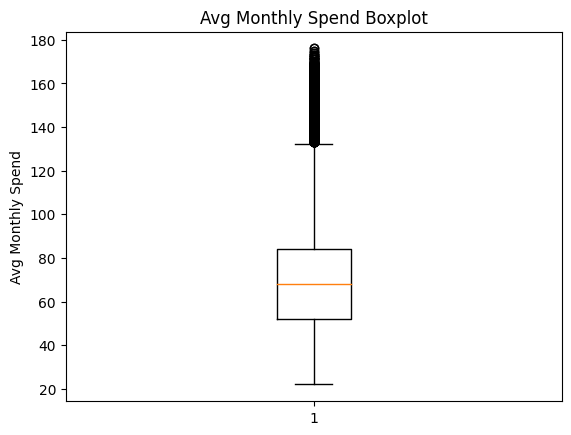



Number of outliers in Avg Monthly Spend: 880


In [25]:
#check for outliers

import matplotlib.pyplot as plt

plt.boxplot(data['Avg Monthly Spend'])
plt.title('Avg Monthly Spend Boxplot')
plt.ylabel('Avg Monthly Spend')
plt.show()

Q1 = data['Avg Monthly Spend'].quantile(0.25)
Q3 = data['Avg Monthly Spend'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data['Avg Monthly Spend'] < lower_bound) | (data['Avg Monthly Spend'] > upper_bound)]

print("\n")

if outliers.shape[0] == 0:
  print("There are no outliers in Avg Monthly Spend")
else:
  print("Number of outliers in Avg Monthly Spend:", outliers.shape[0])

In [26]:
#remove outliers

before_removal = data.shape[0]

data = data[(data['Avg Monthly Spend'] >= lower_bound) & (data['Avg Monthly Spend'] <= upper_bound)]

after_removal = data.shape[0]

if before_removal == after_removal:
  print("No outliers were removed from the dataset")
else:
  print("Rows before outlier removal: ", before_removal)
  print("Rows after outlier removal: ", after_removal)
  print("Number of outliers removed from the dataset: ", before_removal - after_removal)


Rows before outlier removal:  16519
Rows after outlier removal:  15639
Number of outliers removed from the dataset:  880


In [27]:
###NOT USED


#feature scaling in order to ensure that all variables are comparable
#from sklearn.preprocessing import StandardScaler

#scaler = StandardScaler

#data[num_columns] = scaler().fit_transform(data[num_columns])

#print("Scaled Numerical Values Example\n")
#print(data[num_columns].head(4).T)

#print("\nScaled Numerical Values Mean: \n",data[num_columns].mean())
#print("\nScaled Numerical Values Standard Deviation: \n",data[num_columns].std())


In [28]:
#export clean dataset

data.to_csv('../data/processed/Cleaned-Customer-Data.csv', index=False)

print("Cleaned dataset saved as Cleaned-Customer-Data.csv")
print("Final Dataset Shape:", data.shape)

Cleaned dataset saved as Cleaned-Customer-Data.csv
Final Dataset Shape: (15639, 27)
